In [1]:
import os
import re
import json
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt

import src.custom_fastkan
import importlib
importlib.reload(src.custom_fastkan)
from src.custom_fastkan import FastKAN

from sklearn.metrics import mean_squared_error, r2_score

device = torch.device("mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu"))
print(f"Using device: {device}")

Using device: mps


In [2]:
# Configuration
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
if torch.backends.mps.is_available():
    torch.mps.manual_seed(SEED)

# Quick dev-mode switch (keeps runtime low)
SMOKE_TEST = False

# Location of the cloned benchmark repo (created earlier under external/)
BENCH_ROOT = Path('external/ml4acopf_benchmark')
assert BENCH_ROOT.exists(), f"Missing benchmark repo at {BENCH_ROOT.resolve()}"

# Choose a network and a property (vnnlib) to define input bounds
NETWORK = '300_ieee'  # options: '14_ieee', '118_ieee', '300_ieee'
PROP = 2  # property id; for 300_ieee available examples include 2,3,4,105

# Choose the ONNX model variant
ONNX_VARIANT = 'ml4acopf'  # options: 'ml4acopf', 'ml4acopf-linear-residual', 'ml4acopf-linear-nonresidual'

# Dataset generation
N_SAMPLES = 2000
BATCH_INFER = 512

# Train settings
BATCH_SIZE = 256
NUM_EPOCHS = 50
PATIENCE = 10

if SMOKE_TEST:
    N_SAMPLES = 50
    NUM_EPOCHS = 3
    BATCH_SIZE = 64

print('Config:', {'NETWORK': NETWORK, 'PROP': PROP, 'ONNX_VARIANT': ONNX_VARIANT, 'N_SAMPLES': N_SAMPLES})

Config: {'NETWORK': '300_ieee', 'PROP': 2, 'ONNX_VARIANT': 'ml4acopf', 'N_SAMPLES': 2000}


In [3]:
def get_paths(network: str, prop: int, variant: str):
    onnx_name = f"{network}_{variant}.onnx"
    vnnlib_name = f"{network}_prop{prop}.vnnlib"
    onnx_path = BENCH_ROOT / 'onnx' / onnx_name
    vnnlib_path = BENCH_ROOT / 'vnnlib' / vnnlib_name
    if not onnx_path.exists():
        raise FileNotFoundError(f"ONNX not found: {onnx_path}")
    if not vnnlib_path.exists():
        raise FileNotFoundError(f"VNNLIB not found: {vnnlib_path}")
    return onnx_path, vnnlib_path

onnx_path, vnnlib_path = get_paths(NETWORK, PROP, ONNX_VARIANT)
print('ONNX:', onnx_path)
print('VNNLIB:', vnnlib_path)

ONNX: external/ml4acopf_benchmark/onnx/300_ieee_ml4acopf.onnx
VNNLIB: external/ml4acopf_benchmark/vnnlib/300_ieee_prop2.vnnlib


In [4]:
# Minimal vnnlib bound parser
# We only need bounds of the form:
#   (assert (<= X_i <float>))
#   (assert (>= X_i <float>))

_re_le = re.compile(r"\(assert\s+\(<=\s+X_(\d+)\s+([-+eE0-9\.]+)\)\)")
_re_ge = re.compile(r"\(assert\s+\(>=\s+X_(\d+)\s+([-+eE0-9\.]+)\)\)")

def parse_vnnlib_input_bounds(vnnlib_file: Path):
    lbs = {}
    ubs = {}
    with open(vnnlib_file, 'r') as f:
        for line in f:
            line = line.strip()
            m = _re_le.match(line)
            if m:
                idx = int(m.group(1))
                val = float(m.group(2))
                ubs[idx] = val
                continue
            m = _re_ge.match(line)
            if m:
                idx = int(m.group(1))
                val = float(m.group(2))
                lbs[idx] = val
                continue

    if not lbs or not ubs:
        raise ValueError(f"No X_i bounds found in {vnnlib_file}")

    n = max(max(lbs.keys()), max(ubs.keys())) + 1
    lb = np.full((n,), np.nan, dtype=np.float32)
    ub = np.full((n,), np.nan, dtype=np.float32)
    for i in range(n):
        if i not in lbs or i not in ubs:
            raise ValueError(f"Missing bound for X_{i} in {vnnlib_file}")
        lb[i] = lbs[i]
        ub[i] = ubs[i]
        if not (lb[i] <= ub[i]):
            raise ValueError(f"Invalid bounds for X_{i}: lb={lb[i]}, ub={ub[i]}")
    return lb, ub

lb, ub = parse_vnnlib_input_bounds(vnnlib_path)
print('Input dim from vnnlib:', lb.shape[0])
print('Example bounds X_0:', (lb[0], ub[0]))

Input dim from vnnlib: 402
Example bounds X_0: (0.81022584, 0.99027604)


In [5]:
# Build dataset by sampling within bounds and querying ONNX model
import onnxruntime as ort

def make_onnx_session(onnx_model_path: Path):
    sess_options = ort.SessionOptions()
    sess_options.intra_op_num_threads = 1
    return ort.InferenceSession(str(onnx_model_path), sess_options=sess_options)

sess = make_onnx_session(onnx_path)
input_info = sess.get_inputs()[0]
output_info = sess.get_outputs()[0]
input_name = input_info.name
output_name = output_info.name

print('ONNX input:', input_name, input_info.shape)
print('ONNX output:', output_name, output_info.shape)

assert input_info.shape[1] == lb.shape[0], (
    f"Mismatch: ONNX expects {input_info.shape[1]} but vnnlib has {lb.shape[0]}"
 )

fixed_batch_1 = isinstance(input_info.shape[0], int) and input_info.shape[0] == 1
if fixed_batch_1:
    print('Note: ONNX model has fixed batch=1; inference will run one sample at a time.')

def sample_uniform(lb: np.ndarray, ub: np.ndarray, n: int, rng: np.random.Generator):
    u = rng.random((n, lb.shape[0]), dtype=np.float32)
    return lb[None, :] + (ub - lb)[None, :] * u

def infer_batched(sess, input_name: str, output_name: str, X: np.ndarray, batch: int):
    # Some benchmark ONNX models are exported with fixed batch dimension = 1.
    # In that case, we must run inference with shape (1, input_dim) per call.
    if fixed_batch_1:
        ys = []
        for i in range(X.shape[0]):
            xb = X[i:i+1].astype(np.float32, copy=False)
            yb = sess.run([output_name], {input_name: xb})[0]
            ys.append(yb.astype(np.float32, copy=False))
            if (i + 1) % 1000 == 0:
                print(f'Inferred {i+1}/{X.shape[0]} samples...')
        return np.concatenate(ys, axis=0)

    ys = []
    for i in range(0, X.shape[0], batch):
        xb = X[i:i+batch].astype(np.float32, copy=False)
        yb = sess.run([output_name], {input_name: xb})[0]
        ys.append(yb.astype(np.float32, copy=False))
    return np.concatenate(ys, axis=0)

cache_dir = Path('data') / 'acopf_generated'
cache_dir.mkdir(parents=True, exist_ok=True)
cache_path = cache_dir / f"{NETWORK}_{ONNX_VARIANT}_prop{PROP}_n{N_SAMPLES}.npz"

if cache_path.exists():
    d = np.load(cache_path)
    X = d['X']
    Y = d['Y']
    print('Loaded cached dataset:', cache_path)
else:
    rng = np.random.default_rng(SEED)
    X = sample_uniform(lb, ub, N_SAMPLES, rng)
    Y = infer_batched(sess, input_name, output_name, X, BATCH_INFER)
    np.savez_compressed(cache_path, X=X, Y=Y, lb=lb, ub=ub)
    print('Saved dataset cache:', cache_path)

print('X:', X.shape, 'Y:', Y.shape, 'dtype:', X.dtype, Y.dtype)

ONNX input: onnx::Gemm_0 [1, 402]
ONNX output: 194 [1, 3804]
Note: ONNX model has fixed batch=1; inference will run one sample at a time.
Loaded cached dataset: data/acopf_generated/300_ieee_ml4acopf_prop2_n2000.npz
X: (2000, 402) Y: (2000, 3804) dtype: float32 float32


In [6]:
# Train/val/test split + normalization
n = X.shape[0]
idx = np.random.default_rng(SEED).permutation(n)
n_train = int(0.7 * n)
n_val = int(0.15 * n)
train_idx = idx[:n_train]
val_idx = idx[n_train:n_train+n_val]
test_idx = idx[n_train+n_val:]

X_train, Y_train = X[train_idx], Y[train_idx]
X_val, Y_val = X[val_idx], Y[val_idx]
X_test, Y_test = X[test_idx], Y[test_idx]

x_mean = X_train.mean(axis=0)
x_std = X_train.std(axis=0) + 1e-8
y_mean = Y_train.mean(axis=0)
y_std = Y_train.std(axis=0) + 1e-8

X_train_n = (X_train - x_mean) / x_std
X_val_n = (X_val - x_mean) / x_std
X_test_n = (X_test - x_mean) / x_std

Y_train_n = (Y_train - y_mean) / y_std
Y_val_n = (Y_val - y_mean) / y_std
Y_test_n = (Y_test - y_mean) / y_std

print('Split:', X_train_n.shape, X_val_n.shape, X_test_n.shape)
print('Dims:', {'input_dim': X_train_n.shape[1], 'output_dim': Y_train_n.shape[1]})

Split: (1400, 402) (300, 402) (300, 402)
Dims: {'input_dim': 402, 'output_dim': 3804}


In [7]:
# Torch datasets + dataloaders
from torch.utils.data import TensorDataset, DataLoader

X_train_t = torch.tensor(X_train_n, dtype=torch.float32).to(device)
Y_train_t = torch.tensor(Y_train_n, dtype=torch.float32).to(device)
X_val_t = torch.tensor(X_val_n, dtype=torch.float32).to(device)
Y_val_t = torch.tensor(Y_val_n, dtype=torch.float32).to(device)
X_test_t = torch.tensor(X_test_n, dtype=torch.float32).to(device)
Y_test_t = torch.tensor(Y_test_n, dtype=torch.float32).to(device)

train_loader = DataLoader(TensorDataset(X_train_t, Y_train_t), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, Y_val_t), batch_size=BATCH_SIZE, shuffle=False)

input_dim = X_train_n.shape[1]
output_dim = Y_train_n.shape[1]
print(f"Model: {input_dim} inputs → {output_dim} outputs")

Model: 402 inputs → 3804 outputs


In [8]:
def train_model(model, optimizer, criterion, train_loader, X_val_t, Y_val_t, num_epochs: int, patience: int):
    train_losses = []
    val_losses = []
    best_val = float('inf')
    best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
    patience_counter = 0

    for epoch in range(num_epochs):
        model.train()
        total = 0.0
        nb = 0
        for xb, yb in train_loader:
            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            optimizer.step()
            total += loss.item()
            nb += 1

        avg_train = total / max(1, nb)
        model.eval()
        with torch.no_grad():
            val_pred = model(X_val_t)
            val_loss = criterion(val_pred, Y_val_t).item()

        train_losses.append(avg_train)
        val_losses.append(val_loss)

        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1}/{num_epochs} - Train MSE: {avg_train:.6f}, Val MSE: {val_loss:.6f}")

        if val_loss < best_val:
            best_val = val_loss
            patience_counter = 0
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

    model.load_state_dict(best_state)
    return train_losses, val_losses

criterion = torch.nn.MSELoss()

In [9]:
# Train KAN
torch.manual_seed(SEED)
np.random.seed(SEED)

kan_model = FastKAN(
    [input_dim, 32, output_dim],
    grid_min=-2.0,
    grid_max=2.0,
    num_grids=8,
    use_base_update=False,
    use_layernorm=False
).to(device)

kan_optimizer = torch.optim.Adam(kan_model.parameters(), lr=1e-3)
print(f"KAN params: {sum(p.numel() for p in kan_model.parameters()):,}")

print('Training KAN...')
kan_train_losses, kan_val_losses = train_model(
    kan_model, kan_optimizer, criterion, train_loader, X_val_t, Y_val_t, NUM_EPOCHS, PATIENCE
)

kan_model.eval()
with torch.no_grad():
    kan_test_pred = kan_model(X_test_t)
    kan_test_loss = criterion(kan_test_pred, Y_test_t).item()
print(f"KAN Test MSE (normalized): {kan_test_loss:.6f}")

KAN params: 1,076,752
Training KAN...
Epoch 5/50 - Train MSE: 0.987550, Val MSE: 0.963453
Epoch 10/50 - Train MSE: 0.982854, Val MSE: 0.963453
Early stopping at epoch 14
KAN Test MSE (normalized): 1.005921


In [10]:
# Train MLP (matching your weather notebook style)
import torch.nn as nn

class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dims, output_dim):
        super().__init__()
        layers = []
        curr = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(curr, h))
            layers.append(nn.BatchNorm1d(h))
            layers.append(nn.ReLU())
            curr = h
        layers.append(nn.Linear(curr, output_dim))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

torch.manual_seed(SEED)
np.random.seed(SEED)

mlp_model = MLP(input_dim=input_dim, hidden_dims=[64], output_dim=output_dim).to(device)
mlp_optimizer = torch.optim.Adam(mlp_model.parameters(), lr=1e-4)
print(f"MLP params: {sum(p.numel() for p in mlp_model.parameters()):,}")

print('Training MLP...')
mlp_train_losses, mlp_val_losses = train_model(
    mlp_model, mlp_optimizer, criterion, train_loader, X_val_t, Y_val_t, NUM_EPOCHS, PATIENCE
)

mlp_model.eval()
with torch.no_grad():
    mlp_test_pred = mlp_model(X_test_t)
    mlp_test_loss = criterion(mlp_test_pred, Y_test_t).item()
print(f"MLP Test MSE (normalized): {mlp_test_loss:.6f}")

MLP params: 273,180
Training MLP...
Epoch 5/50 - Train MSE: 1.144235, Val MSE: 1.090007
Epoch 10/50 - Train MSE: 1.115273, Val MSE: 1.081160
Early stopping at epoch 11
MLP Test MSE (normalized): 1.084207


In [11]:
# Evaluate in original (de-normalized) units
with torch.no_grad():
    kan_pred_n = kan_model(X_test_t).cpu().numpy()
    mlp_pred_n = mlp_model(X_test_t).cpu().numpy()

# de-normalize
kan_pred = kan_pred_n * y_std + y_mean
mlp_pred = mlp_pred_n * y_std + y_mean
y_true = Y_test

kan_mse = mean_squared_error(y_true, kan_pred)
mlp_mse = mean_squared_error(y_true, mlp_pred)
kan_rmse = float(np.sqrt(kan_mse))
mlp_rmse = float(np.sqrt(mlp_mse))
kan_r2 = r2_score(y_true.flatten(), kan_pred.flatten())
mlp_r2 = r2_score(y_true.flatten(), mlp_pred.flatten())

print(f"\n{'='*80}")
print(f"ACOPF ({NETWORK}, prop{PROP}, {ONNX_VARIANT}) — Regression Metrics")
print(f"{'='*80}")
print(f"ONNX IO shapes: in={input_info.shape}, out={output_info.shape}")
print(f"Dataset shapes: X={X.shape}, Y={Y.shape}; split train/val/test={X_train.shape[0]}/{X_val.shape[0]}/{X_test.shape[0]}")
print(f"KAN shape: {[input_dim, 32, output_dim]} params={sum(p.numel() for p in kan_model.parameters()):,}")
print(f"MLP shape: {[input_dim, 64, output_dim]} params={sum(p.numel() for p in mlp_model.parameters()):,}")
print(f"KAN: MSE={kan_mse:.6e}, RMSE={kan_rmse:.6e}, R2={kan_r2:.6f}")
print(f"MLP: MSE={mlp_mse:.6e}, RMSE={mlp_rmse:.6e}, R2={mlp_r2:.6f}")


ACOPF (300_ieee, prop2, ml4acopf) — Regression Metrics
ONNX IO shapes: in=[1, 402], out=[1, 3804]
Dataset shapes: X=(2000, 402), Y=(2000, 3804); split train/val/test=1400/300/300
KAN shape: [402, 32, 3804] params=1,076,752
MLP shape: [402, 64, 3804] params=273,180
KAN: MSE=1.617020e+00, RMSE=1.271621e+00, R2=0.999997
MLP: MSE=1.749968e+00, RMSE=1.322864e+00, R2=0.999997


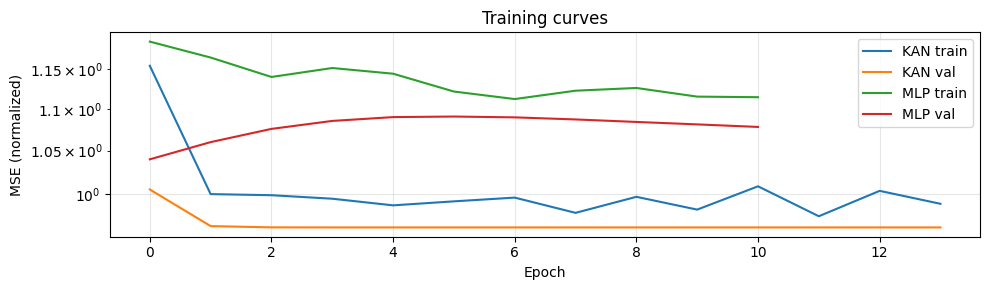

In [12]:
# Loss curves
plt.figure(figsize=(10, 3))
plt.plot(kan_train_losses, label='KAN train')
plt.plot(kan_val_losses, label='KAN val')
plt.plot(mlp_train_losses, label='MLP train')
plt.plot(mlp_val_losses, label='MLP val')
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('MSE (normalized)')
plt.title('Training curves')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
# Save models (mirrors weather notebook)
Path('model_pkls').mkdir(parents=True, exist_ok=True)

run_tag = f"ml4aconpf2"

kan_save_path = f"./model_pkls/acopf_{run_tag}_kan_model.pkl"
torch.save({
    'model_state_dict': kan_model.state_dict(),
    'config': {
        'layers_hidden': [input_dim, 32, output_dim],
        'grid_min': -2.0,
        'grid_max': 2.0,
        'num_grids': 8,
        'use_base_update': False,
        'use_layernorm': False,
    },
    'normalization': {
        'x_mean': x_mean, 'x_std': x_std,
        'y_mean': y_mean, 'y_std': y_std,
    },
    'meta': {
        'network': NETWORK, 'prop': PROP, 'onnx_variant': ONNX_VARIANT,
        'n_samples': int(N_SAMPLES),
        'num_epochs': int(NUM_EPOCHS),
        'onnx_path': str(onnx_path), 'vnnlib_path': str(vnnlib_path),
    }
}, kan_save_path)
print(f"KAN saved to {kan_save_path}")

mlp_save_path = f"./model_pkls/acopf_{run_tag}_mlp_model.pkl"
torch.save({
    'model_state_dict': mlp_model.state_dict(),
    'config': {
        'input_dim': input_dim,
        'hidden_dims': [64],
        'output_dim': output_dim,
    },
    'normalization': {
        'x_mean': x_mean, 'x_std': x_std,
        'y_mean': y_mean, 'y_std': y_std,
    },
    'meta': {
        'network': NETWORK, 'prop': PROP, 'onnx_variant': ONNX_VARIANT,
        'n_samples': int(N_SAMPLES),
        'num_epochs': int(NUM_EPOCHS),
        'onnx_path': str(onnx_path), 'vnnlib_path': str(vnnlib_path),
    }
}, mlp_save_path)
print(f"MLP saved to {mlp_save_path}")

KAN saved to ./model_pkls/acopf_ml4aconpf2_kan_model.pkl
MLP saved to ./model_pkls/acopf_ml4aconpf2_mlp_model.pkl
